In [1]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
df = pd.read_csv("Dataset (1).csv")

#Understanding the Dataset

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [5]:
df.shape

(3900, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [7]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [8]:
df.columns


Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

#Data cleaning 
a.)Look for missing values
b.)Check for duplicate rows
c.)Redundant columns check
d.)Check categorial values
e.) Check the relation between columns such as subscrition and discount and gender .
f.)Check numerical variables

In [9]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique()[:10])


 Customer ID
[ 1  2  3  4  5  6  7  8  9 10]

 Age
[55 19 50 21 45 46 63 27 26 57]

 Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

 Item Purchased
<StringArray>
[  'Blouse',  'Sweater',    'Jeans',  'Sandals', 'Sneakers',    'Shirt',
   'Shorts',     'Coat',  'Handbag',    'Shoes']
Length: 10, dtype: str

 Category
<StringArray>
['Clothing', 'Footwear', 'Outerwear', 'Accessories']
Length: 4, dtype: str

 Purchase Amount (USD)
[53 64 73 90 49 20 85 34 97 31]

 Location
<StringArray>
[     'Kentucky',         'Maine', 'Massachusetts',  'Rhode Island',
        'Oregon',       'Wyoming',       'Montana',     'Louisiana',
 'West Virginia',      'Missouri']
Length: 10, dtype: str

 Size
<StringArray>
['L', 'S', 'M', 'XL']
Length: 4, dtype: str

 Color
<StringArray>
[     'Gray',    'Maroon', 'Turquoise',     'White',  'Charcoal',    'Silver',
      'Pink',    'Purple',     'Olive',      'Gold']
Length: 10, dtype: str

 Season
<StringArray>
['Winter', 'Spring', 'Summer', 'Fa

In [10]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [11]:
missing_pct = (
    df.isnull().mean() * 100
).round(2)

missing_pct.sort_values(ascending=False)

Review Rating             0.95
Customer ID               0.00
Age                       0.00
Gender                    0.00
Category                  0.00
Item Purchased            0.00
Location                  0.00
Size                      0.00
Color                     0.00
Purchase Amount (USD)     0.00
Season                    0.00
Subscription Status       0.00
Shipping Type             0.00
Discount Applied          0.00
Promo Code Used           0.00
Previous Purchases        0.00
Payment Method            0.00
Frequency of Purchases    0.00
dtype: float64

In [12]:
#fixing missing values in review column
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].median())


In [13]:
df['Review Rating'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
3895    False
3896    False
3897    False
3898    False
3899    False
Name: Review Rating, Length: 3900, dtype: bool

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[df.duplicated()]

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases


In [16]:
df['Customer ID'].nunique()

3900

In [17]:
df['Customer ID'].duplicated().sum()

np.int64(0)

In [18]:
# Merge duplicate frequency categories
df['Frequency of Purchases'] = df['Frequency of Purchases'].replace({'Every 3 Months': 'Quarterly'})

In [19]:
df[ 'Frequency of Purchases']

0       Fortnightly
1       Fortnightly
2            Weekly
3            Weekly
4          Annually
           ...     
3895         Weekly
3896      Bi-Weekly
3897      Quarterly
3898         Weekly
3899      Quarterly
Name: Frequency of Purchases, Length: 3900, dtype: str

In [20]:
#Redundant columns check
identical = (df['Discount Applied'] == df['Promo Code Used']).all()
print("\nDiscount Applied == Promo Code Used for every row?", identical)
df = df.drop(columns=['Promo Code Used'])


Discount Applied == Promo Code Used for every row? True


In [21]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually


In [22]:
df.shape

(3900, 17)

In [23]:
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

In [24]:
df['Category'].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [25]:
df['Subscription Status'].value_counts()

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

In [26]:
df['Discount Applied'].value_counts()

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

In [27]:
df['Frequency of Purchases'].value_counts()

Frequency of Purchases
Quarterly      1147
Annually        572
Monthly         553
Bi-Weekly       547
Fortnightly     542
Weekly          539
Name: count, dtype: int64

In [28]:
#Document the gender/subscription/discount confound (flag only, we don't 'fix' it — we just won't use it causally)
gender_sub = pd.crosstab(df['Gender'], df['Subscription Status'])
gender_disc = pd.crosstab(df['Gender'], df['Discount Applied'])
sub_disc_among_subscribed = df.loc[df['Subscription Status']=='Yes', 'Discount Applied'].value_counts(normalize=True)

print("\nSubscription Status by Gender:\n", gender_sub)
print("\nDiscount Applied by Gender:\n", gender_disc)
print("\nOf all subscribed customers, % who also have a discount applied:\n", sub_disc_among_subscribed*100)



Subscription Status by Gender:
 Subscription Status    No   Yes
Gender                         
Female               1248     0
Male                 1599  1053

Discount Applied by Gender:
 Discount Applied    No   Yes
Gender                      
Female            1248     0
Male               975  1677

Of all subscribed customers, % who also have a discount applied:
 Discount Applied
Yes    100.0
Name: proportion, dtype: float64


In [29]:
#Check Numerical Variables
df[['Age',
    'Purchase Amount (USD)',
    'Previous Purchases',
    'Review Rating']].describe()


,Age,Purchase Amount (USD),Previous Purchases,Review Rating
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,25.351538,3.750538
std,15.207589,23.685392,14.447125,0.713589
min,18.000000,20.000000,1.000000,2.500000
25%,31.000000,39.000000,13.000000,3.100000
50%,44.000000,60.000000,25.000000,3.800000
75%,57.000000,81.000000,38.000000,4.400000
max,70.000000,100.000000,50.000000,5.000000


In [30]:
#Check for impossible values
print("Age <= 0:", (df['Age'] <= 0).sum())
print("Purchase amount <= 0:", (df['Purchase Amount (USD)'] <= 0).sum())
print("Previous purchases < 0:", (df['Previous Purchases'] < 0).sum())
print("Rating outside 1-5:",
      ((df['Review Rating'] < 1) | (df['Review Rating'] > 5)).sum())

Age <= 0: 0
Purchase amount <= 0: 0
Previous purchases < 0: 0
Rating outside 1-5: 0


## Step 3 — Feature engineering: turning raw columns into business metrics



| Feature | What it captures | Why it matters |
|---|---|---|
| `Purchase_Freq_Per_Year` | Converts the text cadence (`Weekly`, `Monthly`...) into a number of purchases/year | Lets us do math and compare cadence across customers |
| `Est_Tenure_Years` | `Previous Purchases ÷ Purchase_Freq_Per_Year` | A proxy for "how long has this person likely been a customer" — the dataset has no join date, so we estimate it from how many times they've bought and how often |
| `Total_Spend_Proxy` | `Purchase Amount × (Previous Purchases + 1)` | A stand-in for total customer revenue — since we only have one transaction row per customer, we scale the observed order value by their purchase history |
| `Promo_Reliant` | 1 if `Discount Applied = Yes`, else 0 | Direct signal: did this customer's business come with a discount? |
| `Promo_Dependency_Score` | `0.6 × Promo_Reliant + 0.4 × (not subscribed)` | A single 0–1 score: customers who both use discounts *and* have no paid/subscribed relationship with the brand are the most "rented," not "owned" |
| `Satisfaction_Flag` | Buckets `Review Rating` into Low / Medium / High | Makes satisfaction usable in group-by analysis, not just a raw number |


In [31]:
#convert a text-based purchase frequency label into a numeric value
freq_map = {
    'Weekly': 52, 'Bi-Weekly': 26, 'Fortnightly': 26,
    'Monthly': 12, 'Quarterly': 4, 'Annually': 1
}
df['Purchase_Freq_Per_Year'] = df['Frequency of Purchases'].map(freq_map)

In [32]:
df['Purchase_Freq_Per_Year']

0       26
1       26
2       52
3       52
4        1
        ..
3895    52
3896    26
3897     4
3898    52
3899     4
Name: Purchase_Freq_Per_Year, Length: 3900, dtype: int64

In [33]:
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,Purchase_Freq_Per_Year
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,26
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,26
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,52
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,52
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,1


In [34]:
#"Estimating Customer Tenure from Purchase History and Frequency"
df['Est_Tenure_Years'] = (df['Previous Purchases'] / df['Purchase_Freq_Per_Year']).clip(upper=10)

In [35]:
df['Est_Tenure_Years']

0        0.538462
1        0.076923
2        0.442308
3        0.942308
4       10.000000
          ...    
3895     0.615385
3896     1.576923
3897     6.000000
3898     0.461538
3899     8.250000
Name: Est_Tenure_Years, Length: 3900, dtype: float64

In [36]:
#"Estimating Total Customer Spend via Purchase Amount and Frequency Proxy"
df['Total_Spend_Proxy'] = df['Purchase Amount (USD)'] * (df['Previous Purchases'] + 1)

In [37]:
# 1 if `Discount Applied = Yes`, else 0 
df['Promo_Reliant'] = (df['Discount Applied'] == 'Yes').astype(int)

In [38]:
# A single 0–1 score: customers who both use discounts *and* have no paid/subscribed relationship with the brand are the most "rented," not "owned" 
df['Promo_Dependency_Score'] = (
    0.6 * df['Promo_Reliant'] + 0.4 * (df['Subscription Status'] == 'No').astype(int)
).round(2)

In [39]:
#Buckets `Review Rating` into Low / Medium / High
df['Satisfaction_Flag'] = pd.cut(
    df['Review Rating'], bins=[0, 3.0, 4.0, 5.01], labels=['Low', 'Medium', 'High']
)

In [40]:
df[['Customer ID','Purchase_Freq_Per_Year','Est_Tenure_Years','Total_Spend_Proxy',
    'Promo_Reliant','Promo_Dependency_Score','Satisfaction_Flag']].head()


,Customer ID,Purchase_Freq_Per_Year,Est_Tenure_Years,Total_Spend_Proxy,Promo_Reliant,Promo_Dependency_Score,Satisfaction_Flag
0,1,26,0.538462,795,1,0.6,Medium
1,2,26,0.076923,192,1,0.6,Medium
2,3,52,0.442308,1752,1,0.6,Medium
3,4,52,0.942308,4500,1,0.6,Medium
4,5,1,10.000000,1568,1,0.6,Low


In [41]:
#"Is loyalty better defined by how often someone buys, or by how satisfied and committed they are?" 
def z(s):
    return (s - s.mean()) / s.std()

df['LoyaltyA_raw'] = (
    z(df['Previous Purchases']) + z(df['Purchase_Freq_Per_Year']) +
    (df['Subscription Status'] == 'Yes').astype(int)
)

df['LoyaltyB_raw'] = (
    z(df['Review Rating']) + z(df['Est_Tenure_Years']) + (1 - df['Promo_Reliant'])
)

corr_A = df['LoyaltyA_raw'].corr(df['Total_Spend_Proxy'])
corr_B = df['LoyaltyB_raw'].corr(df['Total_Spend_Proxy'])
print(f"Definition A (Frequency Loyalty)     correlation with revenue proxy: {corr_A:.3f}")
print(f"Definition B (Engaged-Value Loyalty) correlation with revenue proxy: {corr_B:.3f}")


Definition A (Frequency Loyalty)     correlation with revenue proxy: 0.520
Definition B (Engaged-Value Loyalty) correlation with revenue proxy: 0.227


**We adopt Definition A (Frequency Loyalty) as the brand's official loyalty score** and split customers into `Low / Medium / High` tiers on it. We also build `Value_Tier` (Bronze/Silver/Gold/Platinum) from `Total_Spend_Proxy`, so we can talk about "value" and "loyalty" as two related-but-different lenses on the same customer.

In [42]:
df['Loyalty_Tier'] = pd.qcut(df['LoyaltyA_raw'], 3, labels=['Low', 'Medium', 'High'])
df['Value_Tier'] = pd.qcut(df['Total_Spend_Proxy'], 4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

# Sanity check: does High loyalty cluster in the top value tiers?
crosstab = pd.crosstab(df['Value_Tier'], df['Loyalty_Tier'])
print(crosstab)
print("\n% of Platinum customers who are also High loyalty:",
      round((df[(df.Value_Tier=='Platinum') & (df.Loyalty_Tier=='High')].shape[0] / df[df.Value_Tier=='Platinum'].shape[0])*100, 1), "%")
print("% of Bronze customers who are Low loyalty:",
      round((df[(df.Value_Tier=='Bronze') & (df.Loyalty_Tier=='Low')].shape[0] / df[df.Value_Tier=='Bronze'].shape[0])*100, 1), "%")


Loyalty_Tier  Low  Medium  High
Value_Tier                     
Bronze        676     210    89
Silver        401     323   256
Gold          194     369   408
Platinum       46     383   545

% of Platinum customers who are also High loyalty: 56.0 %
% of Bronze customers who are Low loyalty: 69.3 %


In [43]:
#saving the cleaned dataset
df.to_csv('customers_engineered.csv', index=False)
df.shape

(3900, 27)

In [44]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Purchase_Freq_Per_Year,Est_Tenure_Years,Total_Spend_Proxy,Promo_Reliant,Promo_Dependency_Score,Satisfaction_Flag,LoyaltyA_raw,LoyaltyB_raw,Loyalty_Tier,Value_Tier
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,26,0.538462,795,1,0.6,Medium,0.721641,-1.775307,Medium,Silver
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,26,0.076923,192,1,0.6,Medium,-0.108975,-1.897922,Medium,Bronze
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,52,0.442308,1752,1,0.6,Medium,2.891333,-1.800852,High,Gold
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,52,0.942308,4500,1,0.6,Medium,4.690999,-1.107472,High,Platinum
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,1,10.000000,1568,1,0.6,Low,0.411104,0.177767,Medium,Gold


In [45]:
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')

def run(query):
    return pd.read_sql_query(query, conn)


In [46]:
### SQL Question 1 — What separates high-value customers from low-value ones, and which profiles show the strongest repeat-purchase behavior?
q1 = '''
SELECT
    Value_Tier,
    COUNT(*)                                            AS customers,
    ROUND(AVG("Previous Purchases"), 1)                 AS avg_prev_purchases,
    ROUND(AVG(Est_Tenure_Years), 2)                      AS avg_tenure_years,
    ROUND(AVG(Promo_Reliant) * 100, 1)                   AS pct_promo_reliant,
    ROUND(AVG("Subscription Status" = 'Yes') * 100, 1)   AS pct_subscribed,
    ROUND(AVG("Review Rating"), 2)                       AS avg_rating
FROM customers
GROUP BY Value_Tier
ORDER BY CASE Value_Tier
    WHEN 'Platinum' THEN 1 WHEN 'Gold' THEN 2 WHEN 'Silver' THEN 3 ELSE 4 END;
'''
run(q1)


,Value_Tier,customers,avg_prev_purchases,avg_tenure_years,pct_promo_reliant,pct_subscribed,avg_rating
0,Platinum,974,39.6,5.28,42.2,27.2,3.79
1,Gold,971,30.5,4.27,44.4,28.4,3.73
2,Silver,980,22.8,3.80,44.9,27.8,3.72
3,Bronze,975,8.5,1.81,40.5,24.6,3.76


In [47]:
### SQL Question 2 — Which seasons and categories are associated with lower-tenure customers vs. those with high previous-purchase counts?
q2 = '''
SELECT
    Season,
    Category,
    COUNT(*)                                AS customers,
    ROUND(AVG(Est_Tenure_Years), 2)         AS avg_tenure_years,
    ROUND(AVG("Previous Purchases"), 1)     AS avg_prev_purchases
FROM customers
GROUP BY Season, Category
ORDER BY avg_prev_purchases DESC;
'''
run(q2)


,Season,Category,customers,avg_tenure_years,avg_prev_purchases
0,Summer,Accessories,312,4.05,26.8
1,Winter,Footwear,140,3.79,26.7
2,Winter,Clothing,448,3.76,26.1
3,Spring,Outerwear,81,3.96,26.0
4,Spring,Accessories,301,3.92,25.9
5,Summer,Footwear,160,3.80,25.6
6,Fall,Clothing,427,4.08,25.5
7,Winter,Accessories,303,3.75,25.5
8,Winter,Outerwear,80,3.27,25.2
9,Spring,Clothing,454,3.65,24.8


In [48]:
### SQL Question 3 — Which geographies signal organic demand vs. discount-driven volume?
#"Organic" states = decent average spend but a *low* share of customers relying on a discount. "Discount-chased" states = the opposite.
q3_organic = '''
SELECT Location,
       COUNT(*)                              AS customers,
       ROUND(AVG("Purchase Amount (USD)"),1)  AS avg_spend,
       ROUND(AVG(Promo_Reliant) * 100, 1)     AS pct_promo_reliant
FROM customers
GROUP BY Location
HAVING customers >= 60
ORDER BY pct_promo_reliant ASC, avg_spend DESC
LIMIT 8;
'''
print("Most 'organic' states (low promo reliance, solid spend):")
display(run(q3_organic))

q3_discount = '''
SELECT Location,
       COUNT(*)                              AS customers,
       ROUND(AVG("Purchase Amount (USD)"),1)  AS avg_spend,
       ROUND(AVG(Promo_Reliant) * 100, 1)     AS pct_promo_reliant
FROM customers
GROUP BY Location
HAVING customers >= 60
ORDER BY pct_promo_reliant DESC
LIMIT 8;
'''
print("\nMost discount-chased states:")
display(run(q3_discount))


Most 'organic' states (low promo reliance, solid spend):


,Location,customers,avg_spend,pct_promo_reliant
0,Kansas,63,54.6,23.8
1,Connecticut,78,54.2,33.3
2,Arizona,65,66.6,33.8
3,Maine,77,57.0,35.1
4,Tennessee,77,62.0,36.4
5,Texas,77,61.2,36.4
6,South Dakota,70,60.5,37.1
7,Montana,96,60.3,37.5



Most discount-chased states:


,Location,customers,avg_spend,pct_promo_reliant
0,Indiana,79,58.9,57.0
1,Iowa,69,60.9,52.2
2,Oregon,74,57.3,51.4
3,South Carolina,76,58.4,50.0
4,West Virginia,81,63.9,49.4
5,Missouri,81,57.9,49.4
6,Hawaii,65,57.7,49.2
7,Massachusetts,72,60.9,48.6


In [49]:
#"Is the business successfully building a loyal customer base, or is it reliant on continuous promotional activity?"* We answer this directly by checking how much of total revenue (our spend proxy) comes from promo-reliant customers, and how loyalty and promo-reliance overlap.

q4 = '''
SELECT
    Loyalty_Tier,
    COUNT(*)                                        AS customers,
    ROUND(AVG(Promo_Reliant) * 100, 1)               AS pct_promo_reliant,
    ROUND(SUM(Total_Spend_Proxy), 0)                 AS total_spend_proxy,
    ROUND(SUM(Total_Spend_Proxy) * 100.0 /
        (SELECT SUM(Total_Spend_Proxy) FROM customers), 1) AS pct_of_total_revenue
FROM customers
GROUP BY Loyalty_Tier
ORDER BY CASE Loyalty_Tier WHEN 'High' THEN 1 WHEN 'Medium' THEN 2 ELSE 3 END;
'''
run(q4)


,Loyalty_Tier,customers,pct_promo_reliant,total_spend_proxy,pct_of_total_revenue
0,High,1298,56.7,2834929.0,46.1
1,Medium,1285,40.0,2244726.0,36.5
2,Low,1317,32.4,1073146.0,17.4


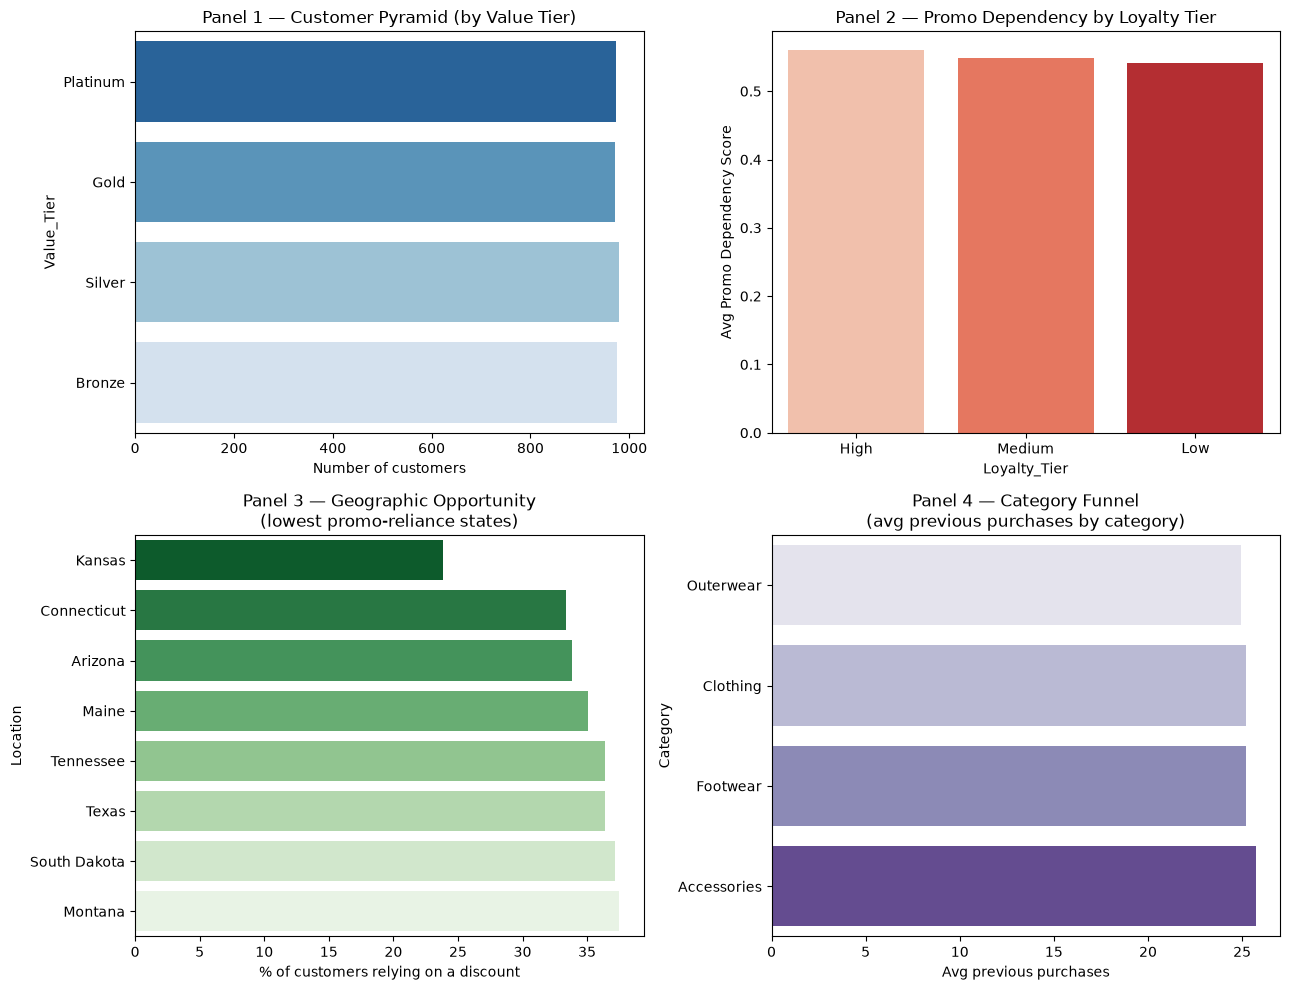

In [50]:
#visualisation of the parameters derived from the query and correlation between them.

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Panel 1: Customer pyramid — how value is distributed
tier_order = ['Platinum', 'Gold', 'Silver', 'Bronze']
tier_counts = df['Value_Tier'].value_counts().reindex(tier_order)
sns.barplot(x=tier_counts.values, y=tier_counts.index, hue=tier_counts.index,
            palette='Blues_r', legend=False, ax=axes[0,0])
axes[0,0].set_title('Panel 1 — Customer Pyramid (by Value Tier)')
axes[0,0].set_xlabel('Number of customers')

# Panel 2: Promo dependency vs loyalty tier
dep_by_loyalty = df.groupby('Loyalty_Tier', observed=True)['Promo_Dependency_Score'].mean().reindex(['High','Medium','Low'])
sns.barplot(x=dep_by_loyalty.index, y=dep_by_loyalty.values, hue=dep_by_loyalty.index,
            palette='Reds', legend=False, ax=axes[0,1])
axes[0,1].set_title('Panel 2 — Promo Dependency by Loyalty Tier')
axes[0,1].set_ylabel('Avg Promo Dependency Score')

# Panel 3: Geographic opportunity — top 8 lowest promo-reliance states with solid spend
geo = df.groupby('Location').agg(
    n=('Customer ID', 'count'),
    avg_spend=('Purchase Amount (USD)', 'mean'),
    pct_promo=('Promo_Reliant', 'mean')
).query('n >= 60').sort_values('pct_promo').head(8)
sns.barplot(x=geo['pct_promo']*100, y=geo.index, hue=geo.index,
            palette='Greens_r', legend=False, ax=axes[1,0])
axes[1,0].set_title('Panel 3 — Geographic Opportunity\n(lowest promo-reliance states)')
axes[1,0].set_xlabel('% of customers relying on a discount')

# Panel 4: Category funnel — avg previous purchases by category (entry-point vs retention)
cat_funnel = df.groupby('Category', observed=True)['Previous Purchases'].mean().sort_values()
sns.barplot(x=cat_funnel.values, y=cat_funnel.index, hue=cat_funnel.index,
            palette='Purples', legend=False, ax=axes[1,1])
axes[1,1].set_title('Panel 4 — Category Funnel\n(avg previous purchases by category)')
axes[1,1].set_xlabel('Avg previous purchases')

plt.tight_layout()
plt.savefig('founder_dashboard.png', dpi=120)
plt.show()
